# Sensor Count Sweep: Darcy Piecewise

- PDE: $-\nabla \cdot (a \nabla u) = 10$, piecewise constant coefficient function $\{5, 10\}$
- Latent dimension: $d = 200$
- Sweep: $n_{\mathrm{obs}} \in \{25, 50, 100\}$, clean observations

In [1]:
import sys, itertools, time, functools
sys.path.insert(0, 'experiment_utils')
from _slurm import parse_slurm_task

PARAMETER_GRID = [
    {"seed": s, "n_obs": n}
    for s, n in itertools.product([42, 123, 7], [25, 50, 100])
]
_params, _task_id = parse_slurm_task(PARAMETER_GRID)

In [2]:
sys.path.insert(0, '..')
import load_this_before_everything_else

import jax
import jax.numpy as jnp
from jax import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import numpyro

from src.problems.darcy_piecewise import DarcyPiecewise, mollifier, a_sample
from src.evaluation.metrics import rmse, cross_correlation
from src.solver.config import InversionConfig, LossWeights, OptimizerConfig, SchedulerConfig

from experiment_utils import (
    crps_ensemble, compute_calibration, ci_width_95, chi2_ppc,
    plot_field_comparison, plot_calibration_overlay,
    plot_sensor_sweep, plot_std_multi_panel,
    plot_sweep_summary_table, plot_trace,
    bootstrap_metric_ci, compute_error_std_correlation,
    compute_sigma_from_map, recommended_nuts_config,
    compute_prior_predictive, build_prior_result,
    make_nf_reparameterized_model,
    load_problem, get_nf_mode, make_log_prior,
    make_gaussian_log_likelihood,
    sample_unconditional_prior,
    run_mcmc, extract_mcmc_diagnostics,
    compute_piecewise_metrics,
    build_mcmc_result, save_experiment_result,
    load_cross_seed_results,
    run_map_estimation,
)

CHECKPOINT_PATH = Path('../runs/final_darcy_piecewise_updated_dims/weights/best.pt')
TRAIN_DATA_PATH = '../data/darcy_piecewise/pwc_train_data1000.mat'
TEST_DATA_PATH = '../data/darcy_piecewise/pwc_test_in.mat'
TEST_IDX = 0
N_OBS_VALUES = [25, 50, 100]
REF_N_OBS = max(N_OBS_VALUES)
NUM_WARMUP = 15000
NUM_SAMPLES = 5000
DECODE_BATCH = 500
NUM_CHAINS = 4
CHAIN_METHOD = 'sequential'
NF_ALPHA = 5.0

SEEDS = [42, 123, 7]
if _task_id is not None:
    SEEDS = [PARAMETER_GRID[_task_id]["seed"]]
    N_OBS_VALUES = [PARAMETER_GRID[_task_id]["n_obs"]]

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}")
print(f"Devices: {jax.devices()}")

HIGH PRECISION MODE ACTIVATED!!!


JAX: 0.4.35, NumPyro: 0.19.0


Devices: [CudaDevice(id=0)]


## 1. Load Trained Model

In [3]:
problem = DarcyPiecewise(
    seed=42,
    train_data_path=TRAIN_DATA_PATH,
    test_data_path=TEST_DATA_PATH,
)
params = load_problem(problem, CHECKPOINT_PATH)
beta_mode, d = get_nf_mode(problem, params)
log_prior_fn = make_log_prior(problem, params)

z_init = 0.5 * jnp.ones(d)

n_points = problem.get_n_points()
print(f"Latent dim: {d}")
print(f"z_init ready (d={d}, NF_ALPHA={NF_ALPHA})")

Loading data...


  Normalization: mean range [7.255, 7.775]
                 std range [2.485, 2.500]
  Train: a=(1000, 841, 1), u=(1000, 841, 1)


  Test: a=(200, 841, 1), u=(200, 841, 1)
Setting up grids and test functions...


  int_grid: (25, 2), v: (25, 1)
Building models...


  Initialized enc: 522,792 params


  Initialized u: 101,205 params


  Initialized a: 578,565 params
  Initialized s1: 101,205 params
  Initialized s2: 101,205 params


  Initialized nf: 1,260,240 params
Loading checkpoint: ../runs/final_darcy_piecewise_updated_dims/weights/best.pt
  Loaded enc
  Loaded u
  Loaded a
  Loaded s1
  Loaded s2
  Loaded nf


Latent dim: 200
z_init ready (d=200, NF_ALPHA=5.0)


In [4]:
def decode_posterior_piecewise(beta_samples, a_true_ref, x_full):
    n_s = beta_samples.shape[0]
    a_pred_list, u_pred_list = [], []

    for i in range(0, n_s, DECODE_BATCH):
        batch = beta_samples[i:i+DECODE_BATCH]
        bs = batch.shape[0]
        x_tile = jnp.tile(x_full, (bs, 1, 1))

        u_pred = problem.models['u'].apply({'params': params['u']}, x_tile, batch)
        if u_pred.ndim == 2:
            u_pred = u_pred[..., None]
        u_pred = mollifier(u_pred.squeeze(-1), x_tile)
        u_pred_list.append(u_pred)

        a_logits = problem.models['a'].apply({'params': params['a']}, x_tile, batch)
        a_prob = jax.nn.sigmoid(a_logits)
        a_decoded = a_sample(a_prob[..., None])
        a_pred_list.append(a_decoded)

    a_pred = jnp.concatenate(a_pred_list, axis=0)
    u_pred = jnp.concatenate(u_pred_list, axis=0)

    a_true_np = np.array(a_true_ref[0, :, 0])
    a_np = np.array(a_pred[:, :, 0])

    pw_metrics = compute_piecewise_metrics(
        a_np, a_true_np, problem.K_LOW, problem.K_HIGH,
        a_err_fn=lambda pred, true: float(cross_correlation(
            jnp.array(pred), jnp.array(true), k_low=problem.K_LOW, k_high=problem.K_HIGH
        )),
    )
    icorr = pw_metrics['a_err']

    spearman_rho, spearman_p = compute_error_std_correlation(
        a_true_np,
        np.array(jnp.mean(a_pred[:, :, 0], axis=0)),
        np.array(jnp.std(a_pred[:, :, 0], axis=0)),
    )

    return {
        'a_pred': a_pred, 'u_pred': u_pred,
        'a_mean': jnp.mean(a_pred, axis=0),
        'a_std': jnp.std(a_pred, axis=0),
        'u_mean': jnp.mean(u_pred, axis=0),
        'u_std': jnp.std(u_pred, axis=0),
        'icorr': icorr,
        'spearman_rho_error_std': spearman_rho,
        'spearman_pvalue_error_std': spearman_p,
        **pw_metrics,
    }

## 2. Inversion Config

In [5]:
inv_config = InversionConfig(
    epochs=200,
    loss_weights=LossWeights(pde=1.0, data=1.0),
    optimizer=OptimizerConfig(type='Adam', lr=0.1),
    scheduler=SchedulerConfig(type='StepLR', step_size=40, gamma=0.1),
)


def run_condition(n_obs, rng_key):
    rng_key, obs_key, mcmc_key = random.split(rng_key, 3)
    label = f"n_obs={n_obs}"
    print(f"\n{'='*60}\n  {label}\n{'='*60}")

    obs_indices = problem.sample_observation_indices(n_points, n_obs, 'random', obs_key)
    obs_data = problem.prepare_observations(sample_indices=[TEST_IDX], obs_indices=obs_indices)
    x_obs = obs_data['x_obs']
    u_obs = obs_data['u_obs']

    map_result = run_map_estimation(problem, params, x_obs, u_obs, x_full, inv_config, rng_key)
    beta_map = map_result['beta_map']
    a_map = map_result['a_map']
    u_map = map_result['u_map']
    _map_time_s = map_result['time_s']
    map_rmse = float(rmse(a_map, a_true[0]))
    print(f"  MAP RMSE (a): {map_rmse:.6f}")
    print("  (Note: RMSE is meaningless for piecewise constant fields — use I_corr instead)")

    preds_map_at_obs = problem.predict_from_beta(params, beta_map, x_obs)
    sigma = compute_sigma_from_map(preds_map_at_obs['u_pred'], u_obs)
    print(f"  sigma (MAP residual): {sigma:.6f}")

    log_lik_fn = make_gaussian_log_likelihood(problem, params, mollifier, x_obs, u_obs)

    nf_model = make_nf_reparameterized_model(
        nf_model=problem.models['nf'],
        nf_params=params['nf'],
        log_likelihood_fn=log_lik_fn,
        d=d,
        nf_alpha=NF_ALPHA,
    )

    nuts_cfg = recommended_nuts_config(d, sigma)
    print(f"  sigma={sigma} | target_accept_prob={nuts_cfg['target_accept_prob']}, "
          f"max_tree_depth={nuts_cfg['max_tree_depth']}")

    mcmc, timing = run_mcmc(
        functools.partial(nf_model, sigma=sigma),
        {"z": z_init}, {}, mcmc_key,
        NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS, CHAIN_METHOD, nuts_cfg,
    )
    mcmc.print_summary(exclude_deterministic=True)

    # Convert z -> beta via NF inverse
    z_01_s = mcmc.get_samples()["z"]
    z_s = 2.0 * z_01_s - 1.0
    beta_s, _ = problem.models['nf'].apply(
        {'params': params['nf']}, z_s, method=problem.models['nf'].inverse
    )

    diag = extract_mcmc_diagnostics(mcmc, sample_name="z", total_samples=NUM_CHAINS * NUM_SAMPLES)

    dec = decode_posterior_piecewise(beta_s, a_true, x_full)

    # Chi-squared posterior predictive check
    u_np = np.array(dec['u_pred'][:, :, 0]) if dec['u_pred'].ndim == 3 else np.array(dec['u_pred'])
    u_pred_at_obs = u_np[:, np.array(obs_indices)]
    u_obs_np = np.array(u_obs[0, :, 0])
    chi2_stat, chi2_pval = chi2_ppc(u_obs_np, u_pred_at_obs, sigma)
    print(f"  Chi2 PPC: chi2={chi2_stat:.2f}, p={chi2_pval:.4f} (df={n_obs})")

    return {
        'label': label, 'n_obs': n_obs, 'sigma': sigma,
        'map_a_err': map_rmse, 'a_map': np.array(a_map),
        'u_map': np.array(u_map),
        'x_obs': np.array(x_obs),
        'beta_samples': np.array(beta_s),
        'beta_by_chain': diag['by_chain'],
        'beta_for_trace': diag['by_chain'][0],
        'a_pred_all': np.array(dec['a_pred'][:, :, 0]),
        'a_mean': np.array(dec['a_mean'][:, 0]),
        'a_std': np.array(dec['a_std'][:, 0]),
        'u_mean': np.array(dec['u_mean']),
        'u_std': np.array(dec['u_std']),
        'icorr': dec['icorr'],
        'ess_min': diag['ess_min'],
        'rhat_max': diag['rhat_max'],
        'rhat_mean': diag['rhat_mean'],
        'n_div': diag['n_div'],
        'reliability_flag': diag['flag'],
        'chi2_ppc': chi2_stat,
        'chi2_ppc_pvalue': chi2_pval,
        'spearman_rho_error_std': dec['spearman_rho_error_std'],
        'spearman_pvalue_error_std': dec['spearman_pvalue_error_std'],
        'warmup_time_s': timing['warmup_time_s'],
        'sampling_time_s': timing['sampling_time_s'],
        'step_time_s': timing['step_time_s'],
        'map_time_s': _map_time_s,
        **{k: dec[k] for k in ('a_err', 'crps_a', 'nll_a', 'coverage_95',
                                'ci_width', 'mean_std', 'cal_levels', 'cal_empirical')},
    }

## 3. Sensor Sweep (Multi-Seed)


######################################################################
# SEED = 42
######################################################################


  x_full: (1, 841, 2), a_true range: [5.0, 10.0]


Prior predictive: a_err=0.5136, CRPS=1.2639, cov95=1.0000

  n_obs=50


  Inversion grid: n_mesh_or_grid=7, n_grid=25


Loss weights: pde=1.0, data=1.0, target=u


...

MCMC warmup: 1093.8s, sampling: 425.3s



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      z[0]      0.50      0.16      0.51      0.25      0.75  15065.11      1.00
      z[1]      0.50      0.15      0.50      0.25      0.74  17278.69      1.00
      z[2]      0.51      0.15      0.51      0.27      0.76  16800.23      1.00
      z[3]      0.50      0.15      0.50      0.25      0.75  17637.71      1.00
      z[4]      0.50      0.15      0.50      0.26      0.76  16276.25      1.00
      z[5]      0.50      0.15      0.50      0.25      0.74  18415.37      1.00
      z[6]      0.50      0.15      0.50      0.25      0.75  17602.83      1.00
      z[7]      0.50      0.15      0.50      0.24      0.75  16346.74      1.00
      z[8]      0.50      0.15      0.50      0.24      0.74  17513.36      1.00
      z[9]      0.50      0.15      0.50      0.25      0.75  17743.03      1.00
     z[10]      0.50      0.15      0.50      0.26      0.76  16912.77      1.00
     z[11]      0.50      0

ESS min=12875.6, R-hat max=1.0006, divergences=0/20000, [PASS] All diagnostics within thresholds


  Chi2 PPC: chi2=1.70, p=1.0000 (df=50)


Saved structured result to: /workspace/experiments/results/structured/sensor_sweep/darcy_piecewise_2026-06-14T16-42-27_seed42.json

  Darcy Piecewise — Sensor Count Sensitivity
  Condition                   I_corr     CRPS(a)    Coverage    CI Width   Sharpness     Diverg.     ESS min       R-hat    Flag
  ------------------------------------------------------------------------------------------------------------------------------
  n_obs=50                  0.809459    0.802737    100.00%     5.000000    2.160739           0     12875.6      1.0006    PASS



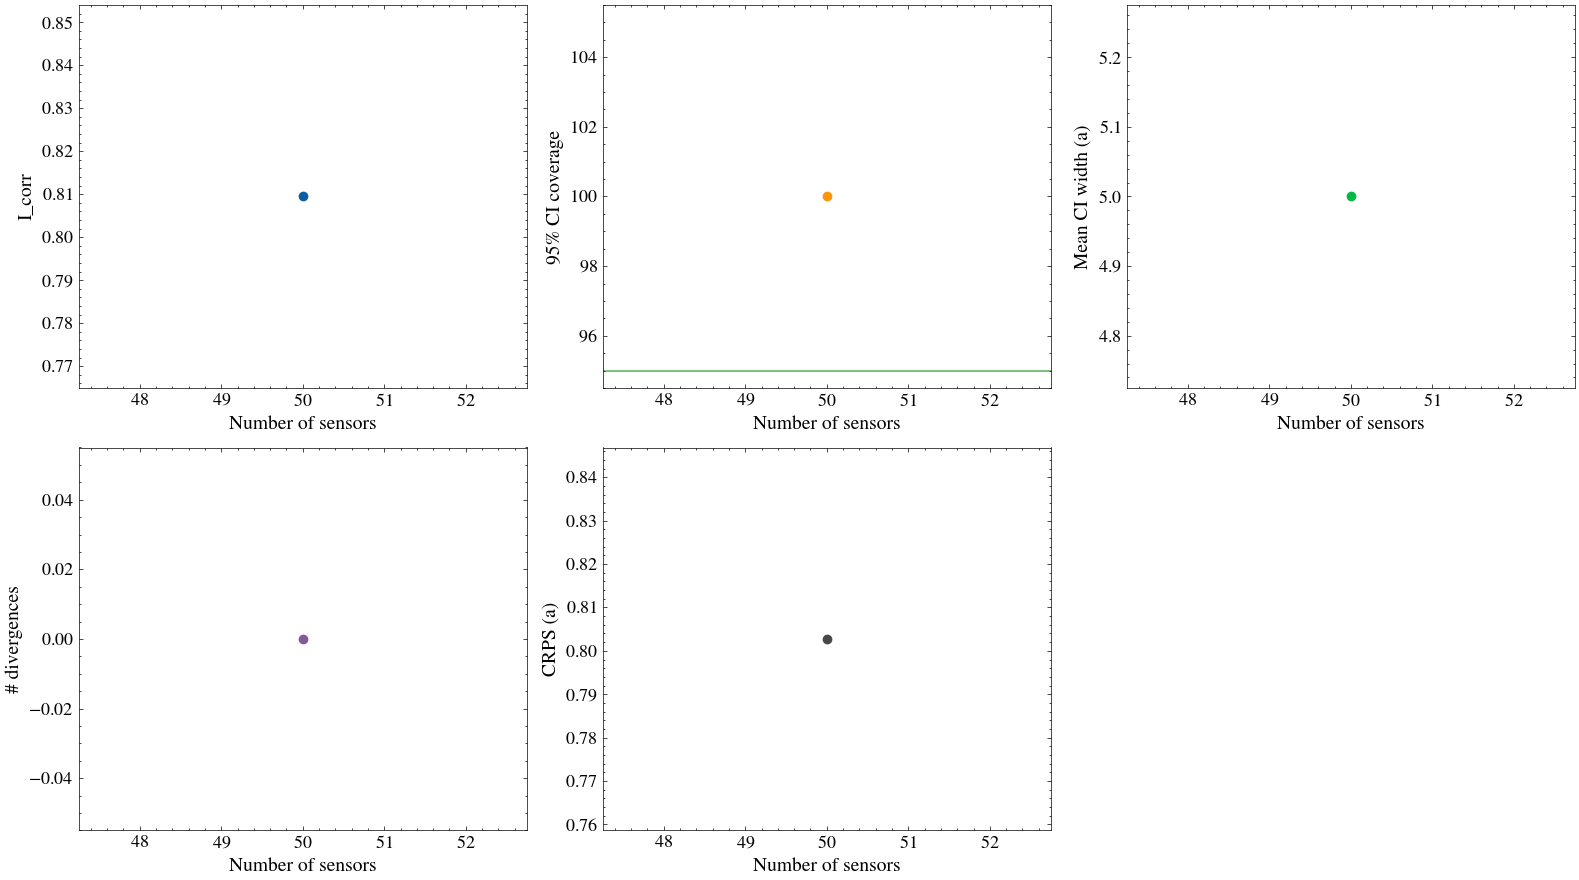

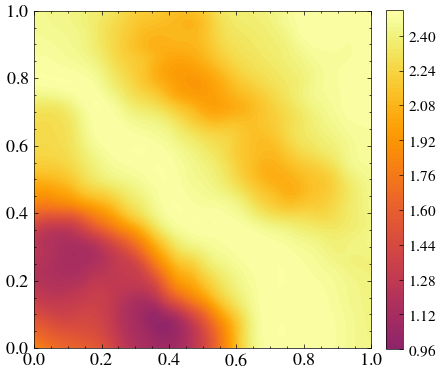

# Panels (a), (b), (c)... correspond to sensor count conditions above


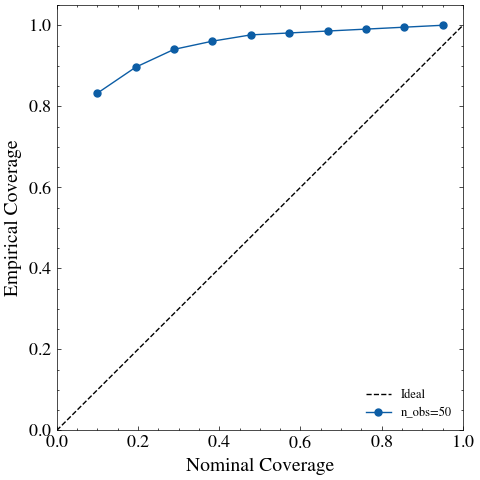

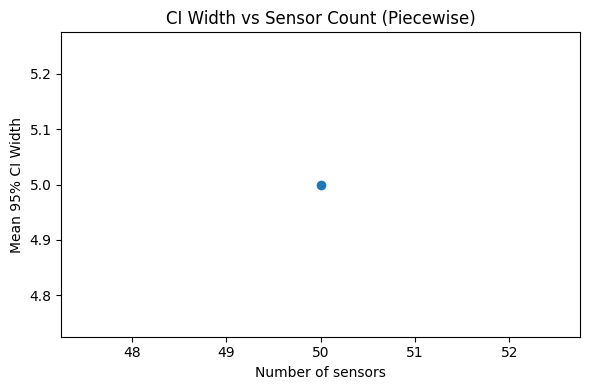

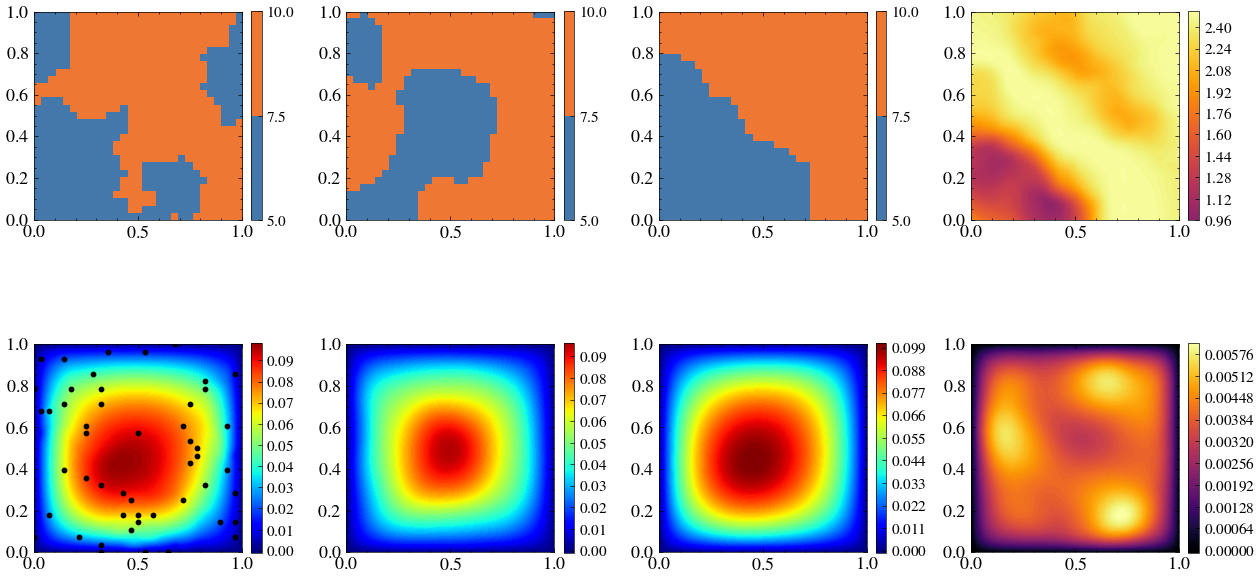

# (a) Ground truth a  (b) MAP a  (c) Posterior mean a  (d) Posterior std a
# (e) Ground truth u  (f) MAP u  (g) Posterior mean u  (h) Posterior std u

Bootstrap CIs on CRPS(a) at each sensor count:
         label      CRPS                  CI


      n_obs=50  0.80274  [0.79955, 0.80602]



n_obs=50 (sigma=0.011019, 4 chains x 5000 samples):
  ESS (z-space):  min=12875.6, mean=16857.5, median=16962.6
  R-hat (z-space): max=1.0006, mean=1.0000, median=1.0000
  Dims with ESS < 10: 0 / 200
  Dims with R-hat > 1.1: 0 / 200
  Divergences: 0 / 20000
  MAP RMSE: 0.383250
  (Note: RMSE is meaningless for piecewise constant fields — use I_corr instead)
  Worst dims by R-hat (z-space):
   dim       ESS     R-hat        mean         std
    55   16487.7    1.0006      0.5022      0.1490
   185   16850.4    1.0005      0.5232      0.1486
    93   17367.3    1.0004      0.4981      0.1492
   198   16484.0    1.0004      0.5206      0.1490
   197   17635.5    1.0004      0.4985      0.1520
    73   17267.4    1.0004      0.5014      0.1519
   130   17087.1    1.0003      0.4920      0.1504
    67   18114.9    1.0003      0.5011      0.1514
   177   17661.6    1.0003      0.4806      0.1495
    31   17532.3    1.0003      0.4980      0.1518


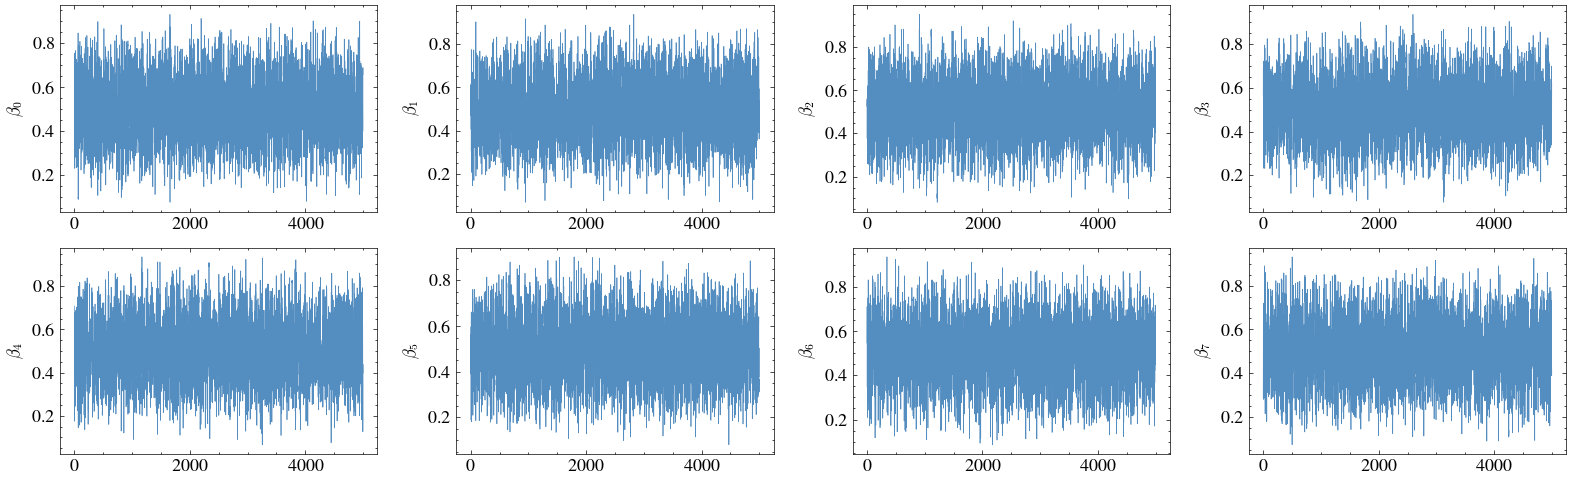

In [6]:
from results_schema import ExperimentResult
from datetime import datetime

def _to_mcmc_result(res):
    return build_mcmc_result(res, NUM_WARMUP, NUM_SAMPLES, NUM_CHAINS)

for SEED in SEEDS:
    _t_total_start = time.time()
    print(f"\n{'#'*70}\n# SEED = {SEED}\n{'#'*70}")

    rng = random.PRNGKey(SEED)

    FIGURE_DIR = Path(f'figures/sensor_sweep_darcy_piecewise/seed{SEED}')
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

    rng, key = random.split(rng)
    obs_indices_full = problem.sample_observation_indices(n_points, REF_N_OBS, 'random', key)
    obs_data_full = problem.prepare_observations(sample_indices=[TEST_IDX], obs_indices=obs_indices_full)
    x_full = obs_data_full['x_full']
    a_true = obs_data_full['a_true']
    u_true = obs_data_full['u_true']

    print(f"  x_full: {x_full.shape}, a_true range: [{float(a_true.min()):.1f}, {float(a_true.max()):.1f}]")

    # ### Prior Predictive Baseline
    a_true_np = np.array(a_true[0, :, 0])
    prior_a_samples, prior_metrics, rng = sample_unconditional_prior(
        problem, params, x_full, a_true_np, rng,
        error_fn=lambda pred, true: float(cross_correlation(
            jnp.where(jnp.array(pred) >= (problem.K_LOW + problem.K_HIGH) / 2, problem.K_HIGH, problem.K_LOW),
            jnp.array(true), k_low=problem.K_LOW, k_high=problem.K_HIGH
        )),
    )
    print(f"Prior predictive: a_err={prior_metrics['a_err']:.4f}, "
          f"CRPS={prior_metrics['crps_a']:.4f}, cov95={prior_metrics['coverage_95']:.4f}")

    # ### Sensor Sweep
    sweep_results = []
    for n_obs in N_OBS_VALUES:
        rng, key = random.split(rng)
        res = run_condition(n_obs, key)
        sweep_results.append(res)

    # ### Save Structured Result
    experiment = ExperimentResult(
        experiment="sensor_sweep",
        problem="darcy_piecewise",
        experiment_type="sweep",
        sweep_var="n_obs",
        seed=SEED,
        timestamp=datetime.now().strftime("%Y-%m-%dT%H:%M:%S"),
        baseline=None,
        prior=build_prior_result(prior_metrics),
        sweep_conditions=[_to_mcmc_result(r) for r in sweep_results],
        total_time_s=time.time() - _t_total_start,
    )

    out_path = save_experiment_result(experiment)
    print(f"Saved structured result to: {out_path}")


    # ### Plots
    labels = [f'n_obs={r["n_obs"]}' for r in sweep_results]
    plot_sweep_summary_table(sweep_results, labels, title='Darcy Piecewise — Sensor Count Sensitivity',
                             use_icorr=True)

    plot_sensor_sweep(sweep_results, save_path=FIGURE_DIR / 'sensor_sweep.png',
                      a_metric_key='icorr', a_metric_label='I_corr')

    x_np = np.array(x_full[0])
    stds = [res['a_std'] for res in sweep_results]
    labels = [res['label'] for res in sweep_results]

    plot_std_multi_panel(
        x_np, stds, labels, grid_shape=(29, 29),
        suptitle='Posterior Std: Sensor Count (Piecewise)',
        save_path=FIGURE_DIR / 'std_multi_panel.png',
    )
    print("# Panels (a), (b), (c)... correspond to sensor count conditions above")

    cal_list = [(r['cal_levels'], r['cal_empirical'], r['label']) for r in sweep_results]
    plot_calibration_overlay(cal_list, save_path=FIGURE_DIR / 'calibration_overlay.png')

    with plt.style.context(['default']):
        fig, ax = plt.subplots(figsize=(6, 4))
        n_obs_vals = [r['n_obs'] for r in sweep_results]
        widths = [r['ci_width'] for r in sweep_results]
        ax.plot(n_obs_vals, widths, 'o-', color='C0')
        ax.set_xlabel('Number of sensors')
        ax.set_ylabel('Mean 95% CI Width')
        ax.set_title('CI Width vs Sensor Count (Piecewise)')
        plt.tight_layout()
        fig.savefig(FIGURE_DIR / 'ci_width_vs_sensors.png', dpi=200, bbox_inches='tight')
        plt.show()

    x_np = np.array(x_full[0])
    a_true_np = np.array(a_true[0, :, 0])

    for res in sweep_results:
        plot_field_comparison(
            x_np, a_true_np,
            np.array(res['a_map'][:, 0]),
            res['a_mean'],
            res['a_std'],
            grid_shape=(29, 29),
            u_true=np.array(u_true[0, :, 0]),
            u_map=np.array(res['u_map'][:, 0]),
            u_mean=np.array(res['u_mean']),
            u_std=np.array(res['u_std']),
            obs_coords=np.array(res['x_obs'][0]),
            save_path=FIGURE_DIR / f'field_comparison_{res["n_obs"]}.png',
            show_abs_error=False,
            piecewise_a_bounds=(5.0, 10.0),
        )
        print("# (a) Ground truth a  (b) MAP a  (c) Posterior mean a  (d) Posterior std a")
        print("# (e) Ground truth u  (f) MAP u  (g) Posterior mean u  (h) Posterior std u")

    # ### Statistical Trend Analysis
    def _crps_a(s, t): return float(np.mean(crps_ensemble(s, t)))

    rng_bs = np.random.default_rng(SEED)
    print("\nBootstrap CIs on CRPS(a) at each sensor count:")
    print(f"  {'label':>12s}  {'CRPS':>8s}  {'CI':>18s}")
    for res in sweep_results:
        a_np = res['a_pred_all']
        ci = bootstrap_metric_ci(a_np, a_true_np, _crps_a, rng=rng_bs)
        print(f"  {res['label']:>12s}  {ci['estimate']:.5f}  [{ci['ci_lo']:.5f}, {ci['ci_hi']:.5f}]")

    # ### Diagnostics
    from numpyro.diagnostics import effective_sample_size, split_gelman_rubin

    for res in sweep_results:
        beta_by_chain = res['beta_by_chain']  # z-space (n_chains, n_samples, d)
        ess = effective_sample_size(beta_by_chain)
        rhat = split_gelman_rubin(beta_by_chain)
        n_chains, n_samples_per_chain = beta_by_chain.shape[0], beta_by_chain.shape[1]
        total_samples = n_chains * n_samples_per_chain

        print(f"\n{res['label']} (sigma={res['sigma']:.6f}, {n_chains} chains x {n_samples_per_chain} samples):")
        print(f"  ESS (z-space):  min={float(ess.min()):.1f}, mean={float(ess.mean()):.1f}, median={float(np.median(ess)):.1f}")
        print(f"  R-hat (z-space): max={float(rhat.max()):.4f}, mean={float(rhat.mean()):.4f}, median={float(np.median(rhat)):.4f}")
        print(f"  Dims with ESS < 10: {int((ess < 10).sum())} / {d}")
        print(f"  Dims with R-hat > 1.1: {int((rhat > 1.1).sum())} / {d}")
        print(f"  Divergences: {res['n_div']} / {total_samples}")
        print(f"  MAP RMSE: {res['map_a_err']:.6f}")
        print("  (Note: RMSE is meaningless for piecewise constant fields — use I_corr instead)")

        worst_rhat_idx = np.argsort(rhat)[::-1][:10]
        z_merged = beta_by_chain.reshape(-1, beta_by_chain.shape[-1])
        print(f"  Worst dims by R-hat (z-space):")
        print(f"  {'dim':>4s}  {'ESS':>8s}  {'R-hat':>8s}  {'mean':>10s}  {'std':>10s}")
        for i in worst_rhat_idx:
            print(f"  {i:4d}  {float(ess[i]):8.1f}  {float(rhat[i]):8.4f}  "
                  f"{float(z_merged[:, i].mean()):10.4f}  "
                  f"{float(z_merged[:, i].std()):10.4f}")

    beta_true = problem.models['enc'].apply({'params': params['enc']}, a_true)[0]
    beta_true_np = np.array(beta_true)

    for res in sweep_results:
        plot_trace(res['beta_for_trace'][:, :8], beta_true=None, num_warmup=0,
                   save_path=FIGURE_DIR / f'trace_{res["label"]}.png')

## Cross-Seed Aggregation Summary

In [7]:
results = load_cross_seed_results("sensor_sweep", "darcy_piecewise")
SUMMARY_METRICS = ["a_err", "crps_a", "nll_a", "coverage_95", "ci_width", "mean_std", "ess_min", "rhat_max", "n_div"]

if len(results) > 1:
    print(f"Cross-Seed Sweep Summary ({len(results)} seeds: {[r.seed for r in results]})\n")

    n_sweep = len(results[0].sweep_conditions) if results[0].sweep_conditions else 0
    for idx in range(n_sweep):
        label = results[0].sweep_conditions[idx].label or f"sweep[{idx}]"
        print(f"\n=== {label} ===")
        print(f"{'Metric':<16s}  {'Mean':>10s}  {'Std':>10s}  {'Min':>10s}  {'Max':>10s}")
        print("-" * 62)
        for m in SUMMARY_METRICS:
            vals = []
            for r in results:
                if r.sweep_conditions and idx < len(r.sweep_conditions):
                    v = getattr(r.sweep_conditions[idx], m, None)
                    if v is not None:
                        vals.append(float(v))
            if vals:
                arr = np.array(vals)
                std_val = float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0
                print(f"{m:<16s}  {float(np.mean(arr)):>10.4f}  {std_val:>10.4f}  {float(np.min(arr)):>10.4f}  {float(np.max(arr)):>10.4f}")
else:
    print(f"Only {len(results)} seed result(s) found - skipping cross-seed summary")

Cross-Seed Sweep Summary (22 seeds: [7, 7, 7, 7, 7, 7, 7, 42, 42, 42, 42, 42, 42, 42, 42, 123, 123, 123, 123, 123, 123, 123])


=== n_obs=25 ===
Metric                  Mean         Std         Min         Max
--------------------------------------------------------------
a_err                 0.8031      0.0225      0.7572      0.8299
crps_a                0.7689      0.0737      0.6638      0.8639
nll_a                 0.4722      0.0396      0.4120      0.5224
coverage_95           0.9995      0.0012      0.9964      1.0000
ci_width              4.8206      0.2564      4.2925      5.0000
mean_std              2.0767      0.1728      1.7571      2.2971
ess_min           14274.8776   1966.3700  11030.8660  17673.8571
rhat_max              1.0005      0.0002      1.0002      1.0008
n_div                 0.2727      0.8827      0.0000      3.0000
